In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as colors

from netCDF4 import Dataset

from pyproj import Proj

In [2]:
with Dataset('particles.nc', 'r') as dset:
    
    R2D = 180. / np.pi
    
    lon = R2D * dset['longitude'][:,:]
    lat = R2D * dset['latitude'][:,:]

## Distribution of initial latitude positions

Because of decreased land area near the poles, a 'uniform' random distribution should have a cosine distribution in latitude (the dashed black line)

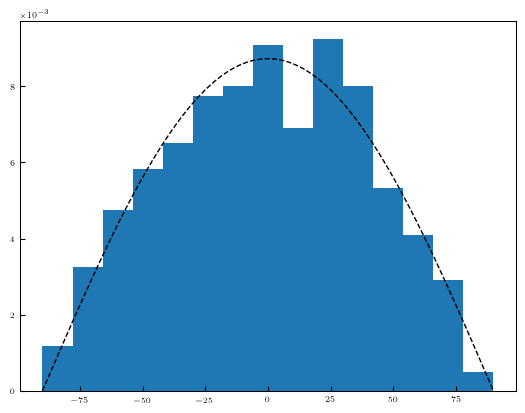

In [3]:
plt.hist( lat[0,:], bins = 'fd', range = (-90, 90), density = True )
plt.plot( np.linspace( -90, 90, 100 ), (0.5/R2D) * np.cos(np.linspace( -np.pi/2, np.pi/2, 100 )), '--k' )
print()

## Distribution of initial longitude positions

The dashed black line shows a uniform distribution in longitude.

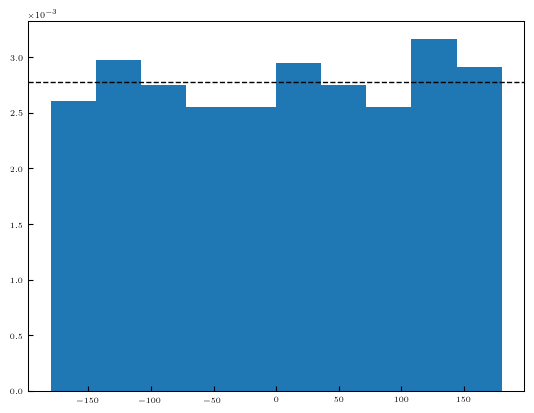

In [4]:
plt.hist( lon[0,:], bins = 'fd', range = (-180, 180), density = True )
plt.gca().axhline( 1./360, color = 'k', linestyle = '--' )
print()

In [14]:
# Create a map projection

lon_targ = 0
lat_targ = 40

proj = Proj( proj='ortho', lon_0 = lon_targ, lat_0 = lat_targ, R = 1 )

LON_proj, LAT_proj = proj( lon, lat )

mask = np.isinf( LON_proj )

lon_proj = np.ma.masked_where( mask, LON_proj )
lat_proj = np.ma.masked_where( mask, LAT_proj )

In [15]:
# Load the background velocity

with Dataset( 'velocity_sample.nc', 'r' ) as dset:
    
    lon_map = dset['longitude'][:]
    lat_map = dset['latitude'][:]
    
    LON, LAT = np.meshgrid( lon_map, lat_map )
    LON, LAT = proj( LON, LAT )
    
    mask_map = np.logical_not(np.isinf( LON )).ravel()
    LON = LON.ravel()[mask_map]
    LAT = LAT.ravel()[mask_map]
    
    speed = np.sqrt( dset['uo'][0,0,:,:]**2 + dset['vo'][0,0,:,:]**2 )
    speed = speed.ravel()[mask_map]

## Here we plot the streamlines on top of a map of current magnitude

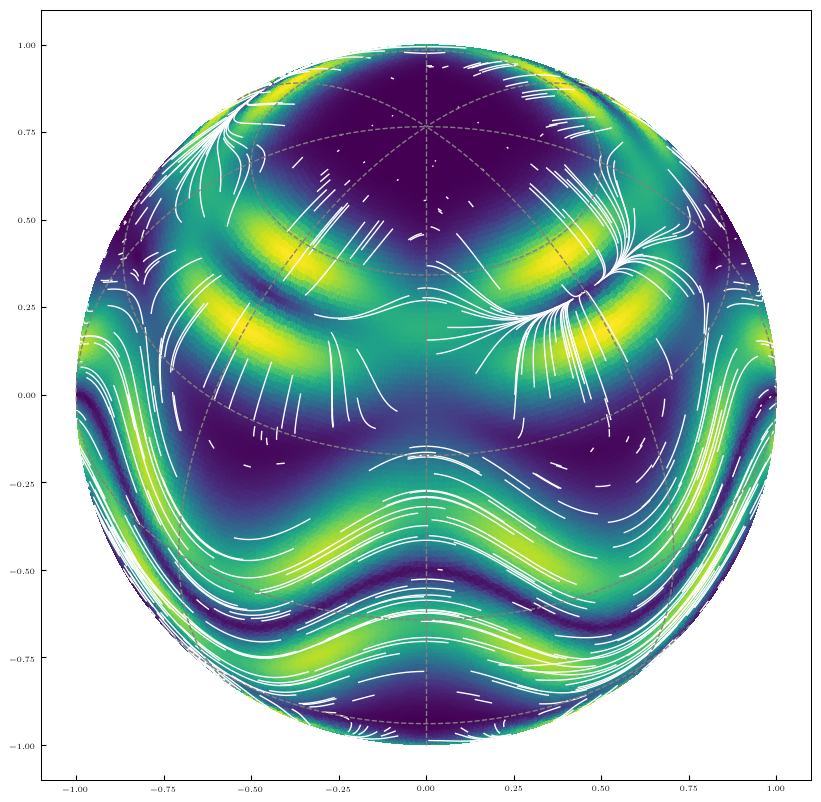

In [17]:
plt.figure( figsize = (10,10) )

plt.tripcolor( LON, LAT, speed, cmap = 'viridis' )

plt.plot( lon_proj, lat_proj, c = 'w' )
print()

plt.gca().set_aspect('equal')

# add some lat/lon lines to show the curvature
for lons in np.arange(-180, 180, 45):
    lats = np.linspace( -90, 90, 200 )
    
    lons_proj, lats_proj = proj( lons * np.ones(len(lats)), lats )
    plt.plot( lons_proj, lats_proj, '--', color = 'gray' )
    
for lats in np.arange(-90, 90, 30):
    lons = np.linspace( -180, 180, 200 )
    
    lons_proj, lats_proj = proj( lons, lats * np.ones(len(lons)) )
    plt.plot( lons_proj, lats_proj, '--', color = 'gray' )